<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/Anomaly_Detection_and_Packet_Inspection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DataSet**

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

network_logs = {
    "Source_IP":[
        "192.168.1.10",
        "192.168.1.11",
        "192.168.1.12",
        "192.168.1.13",
        "192.168.1.14",
        "192.168.1.15",
        "192.168.1.16",
        "192.168.1.17"
    ],

    "Destination_IP":[
        "8.8.8.8",
        "172.16.0.5",
        "8.8.4.4",
        "10.0.0.5",
        "172.16.0.8",
        "8.8.8.8",
        "203.0.113.10",
        "198.51.100.5"
    ],

    "Protocol":[
        "TCP",
        "UDP",
        "TCP",
        "TCP",
        "UDP",
        "TCP",
        "TCP",
        "UDP"
    ],

    "Packets":[
        120,
        180,
        140,
        2500,
        170,
        130,
        3200,
        2900
    ]
}

df = pd.DataFrame(network_logs)
df.head()


,Source_IP,Destination_IP,Protocol,Packets
0,192.168.1.10,8.8.8.8,TCP,120
1,192.168.1.11,172.16.0.5,UDP,180
2,192.168.1.12,8.8.4.4,TCP,140
3,192.168.1.13,10.0.0.5,TCP,2500
4,192.168.1.14,172.16.0.8,UDP,170


**Traffic Analysis**

In [30]:
#1. Find total traffic generated.

total_traffic = df["Packets"].sum()
print("Total Traffic Generated =", total_traffic)

#2. Find average packet count
average_packets = df["Packets"].mean()
print("Average Packet Count =", average_packets)

# 3.	Identify records exceeding average traffic.

high_traffic = df[df["Packets"] > average_packets]
print("\nRecords Exceeding Average Traffic:")
print(high_traffic)

#4. Ranking devices by traffic
ranked_devices = df.sort_values(by="Packets", ascending=False)
print("\nDevices Ranked by Traffic:")
print(ranked_devices[["Source_IP", "Packets"]])

Total Traffic Generated = 9340
Average Packet Count = 1167.5

Records Exceeding Average Traffic:
      Source_IP Destination_IP Protocol  Packets
3  192.168.1.13       10.0.0.5      TCP     2500
6  192.168.1.16   203.0.113.10      TCP     3200
7  192.168.1.17   198.51.100.5      UDP     2900

Devices Ranked by Traffic:
      Source_IP  Packets
6  192.168.1.16     3200
7  192.168.1.17     2900
3  192.168.1.13     2500
1  192.168.1.11      180
4  192.168.1.14      170
2  192.168.1.12      140
5  192.168.1.15      130
0  192.168.1.10      120


**Packet Inspection**

In [31]:
# Suspicious devices
suspicious_devices = df[df["Packets"] > 1000]

print("Suspicious Devices:\n")
print(suspicious_devices[["Source_IP", "Destination_IP", "Protocol", "Packets"]])

# Possible malware communication
malware_records = df[
    (df["Packets"] > 1500)
]

print("\nPossible Malware Communication:")
print(malware_records[["Source_IP", "Destination_IP", "Protocol", "Packets"]])

# Possible DDoS activity
ddos_records = df[df["Packets"] > 2000]

print("\nPossible DDoS Activity:")
print(ddos_records[["Source_IP", "Destination_IP", "Protocol", "Packets"]])

# Systems requiring immediate investigation
print("\nSystems Requiring Immediate Investigation:")
print(ddos_records[["Source_IP", "Destination_IP", "Protocol", "Packets"]])

Suspicious Devices:

      Source_IP Destination_IP Protocol  Packets
3  192.168.1.13       10.0.0.5      TCP     2500
6  192.168.1.16   203.0.113.10      TCP     3200
7  192.168.1.17   198.51.100.5      UDP     2900

Possible Malware Communication:
      Source_IP Destination_IP Protocol  Packets
3  192.168.1.13       10.0.0.5      TCP     2500
6  192.168.1.16   203.0.113.10      TCP     3200
7  192.168.1.17   198.51.100.5      UDP     2900

Possible DDoS Activity:
      Source_IP Destination_IP Protocol  Packets
3  192.168.1.13       10.0.0.5      TCP     2500
6  192.168.1.16   203.0.113.10      TCP     3200
7  192.168.1.17   198.51.100.5      UDP     2900

Systems Requiring Immediate Investigation:
      Source_IP Destination_IP Protocol  Packets
3  192.168.1.13       10.0.0.5      TCP     2500
6  192.168.1.16   203.0.113.10      TCP     3200
7  192.168.1.17   198.51.100.5      UDP     2900


**Basic Anomaly Detection**

In [32]:
# Create Anomaly column
df["Anomaly"] = df["Packets"].apply(
    lambda x: "Suspicious" if x > 1000 else "Normal"
)

# Count Normal and Suspicious records
normal_count = (df["Anomaly"] == "Normal").sum()
suspicious_count = (df["Anomaly"] == "Suspicious").sum()

print("\nTotal Normal Records =", normal_count)
print("Total Suspicious Records =", suspicious_count)


print("\nFinal DataFrame")
print(df)



Total Normal Records = 5
Total Suspicious Records = 3

Final DataFrame
      Source_IP Destination_IP Protocol  Packets     Anomaly
0  192.168.1.10        8.8.8.8      TCP      120      Normal
1  192.168.1.11     172.16.0.5      UDP      180      Normal
2  192.168.1.12        8.8.4.4      TCP      140      Normal
3  192.168.1.13       10.0.0.5      TCP     2500  Suspicious
4  192.168.1.14     172.16.0.8      UDP      170      Normal
5  192.168.1.15        8.8.8.8      TCP      130      Normal
6  192.168.1.16   203.0.113.10      TCP     3200  Suspicious
7  192.168.1.17   198.51.100.5      UDP     2900  Suspicious


**Visualization**

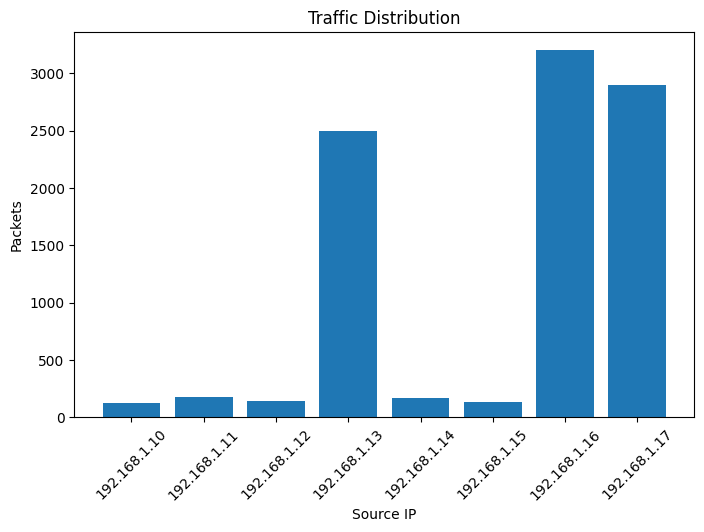

In [33]:

# 1. Traffic Distribution Chart
plt.figure(figsize=(8,5))
plt.bar(df["Source_IP"], df["Packets"])
plt.title("Traffic Distribution")
plt.xlabel("Source IP")
plt.ylabel("Packets")
plt.xticks(rotation=45)
plt.show()



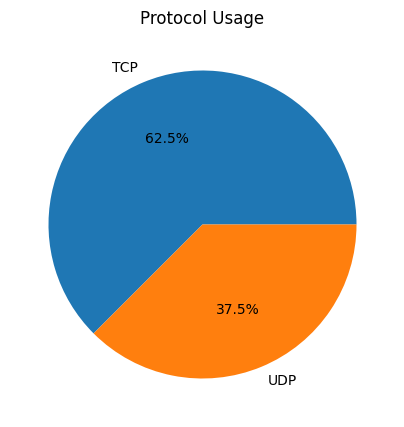

In [36]:
# 2. Protocol Usage Chart
protocol_count = df["Protocol"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(protocol_count, labels=protocol_count.index,
        autopct='%1.1f%%')
plt.title("Protocol Usage")
plt.show()



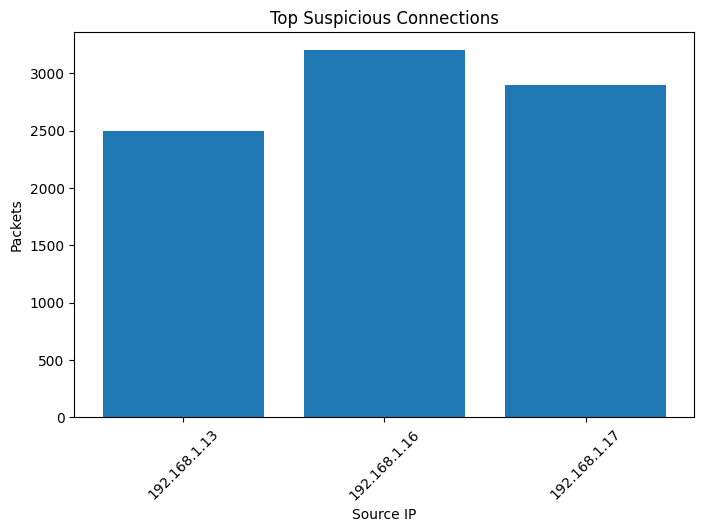

In [35]:
# 3. Top Suspicious Connections Chart
suspicious_df = df[df["Anomaly"]=="Suspicious"]

plt.figure(figsize=(8,5))
plt.bar(suspicious_df["Source_IP"], suspicious_df["Packets"])
plt.title("Top Suspicious Connections")
plt.xlabel("Source IP")
plt.ylabel("Packets")
plt.xticks(rotation=45)
plt.show()